In [3]:
# --- DATASET FOLDERS: Use new batch-2 MRPRO dataset (edit as needed) ---
DATASET_FOLDERS = [
    '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test',
    '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_train',
    '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_val',
    #'../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro'
    # Add more folders as needed
 ]

import os
import h5py
import numpy as np
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import Counter
from tabulate import tabulate
import matplotlib as mpl

def _to_str_from_dataset(ds):
    try:
        return ds.asstr()[()].strip()
    except Exception:
        pass
    obj = ds[()]
    if isinstance(obj, (bytes, bytearray)):
        return bytes(obj).replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
    if np.isscalar(obj):
        if isinstance(obj.item(), (bytes, bytearray)):
            return obj.item().replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        try:
            return str(obj.item())
        except Exception:
            pass
    if isinstance(obj, np.ndarray):
        if obj.dtype == np.uint8:
            return bytes(obj.tobytes()).replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        if obj.dtype.kind == 'S':
            try:
                joined = b"".join(obj.tolist())
            except Exception:
                joined = bytes(obj.tobytes())
            return joined.replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        if obj.dtype.kind == 'U':
            try:
                return "".join(obj.tolist()).strip()
            except Exception:
                return str(obj)
    return str(obj)

def _extract_text(elem):
    return elem.text.strip() if elem is not None and elem.text is not None else None

def _strip_xml_ns_text(xml_str):
    try:
        root = ET.fromstring(xml_str)
    except Exception:
        return None
    for e in root.iter():
        if isinstance(e.tag, str) and '}' in e.tag:
            e.tag = e.tag.split('}', 1)[1]
        if e.attrib:
            e.attrib = { (k.split('}',1)[1] if '}' in k else k): v for k, v in e.attrib.items() }
    return root

def parse_header_fields(header_str):
    root = _strip_xml_ns_text(header_str)
    if root is None:
        return {
            'patient_id': None,
            'tStudyDescription': None,
            'sliceCount': None,
        }
    # patient id (prefer subjectInformation/patientID, fallback to userParameters PatientLOID)
    patient_id = _extract_text(root.find('.//subjectInformation/patientID'))
    if not patient_id:
        for ups in root.findall('.//userParameters/userParameterString'):
            name = _extract_text(ups.find('name'))
            if name == 'PatientLOID':
                patient_id = _extract_text(ups.find('value'))
                if patient_id:
                    break
    # tStudyDescription (userParameterString with name == tStudyDescription)
    tStudyDescription = None
    for ups in root.findall('.//userParameters/userParameterString'):
        name = _extract_text(ups.find('name'))
        if name == 'tStudyDescription':
            tStudyDescription = _extract_text(ups.find('value'))
            break
    # sliceCount: from kspace shape (handled later)
    return {
        'patient_id': patient_id,
        'tStudyDescription': tStudyDescription,
        'sliceCount': None, # will fill later
    }

# --- Gather all .h5 files from all DATASET_FOLDERS ---
h5_paths = []
for folder in DATASET_FOLDERS:
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if fname.endswith('.h5'):
            h5_paths.append(os.path.join(folder, fname))

print(f'Found {len(h5_paths)} H5 files in: {DATASET_FOLDERS}')

# --- Build records list with patientID, tStudyDescription, filename, and slice_count ---
records = []
total_slices = 0
for path in h5_paths:
    try:
        with h5py.File(path, 'r') as f:
            header_str = _to_str_from_dataset(f['ismrmrd_header']) if 'ismrmrd_header' in f else None
            meta = parse_header_fields(header_str) if header_str else {'patient_id': None, 'tStudyDescription': None, 'sliceCount': None}
            # sliceCount: from kspace shape if available
            slice_count = None
            if 'kspace' in f:
                ks_shape = f['kspace'].shape
                if len(ks_shape) >= 1:
                    slice_count = int(ks_shape[0])
            meta['sliceCount'] = slice_count
            if meta['patient_id'] and meta['tStudyDescription'] and meta['sliceCount'] is not None:
                total_slices += meta['sliceCount']
                records.append({
                    'patientID': meta['patient_id'],
                    'tStudyDescription': meta['tStudyDescription'],
                    'fname': os.path.basename(path),
                    'slice_count': meta['sliceCount']
                })
    except Exception as e:
        print(f'Error reading file {path}: {e}')

print(f'Total valid records: {len(records)}')
print(f'Total slices across all records: {total_slices}')

Found 2653 H5 files in: ['../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test', '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_train', '../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_val']
Total valid records: 2653
Total slices across all records: 79582
Total valid records: 2653
Total slices across all records: 79582


In [4]:
# --- Split stats: files, patients, slices (test/train/val + total) ---
from collections import defaultdict
from tabulate import tabulate
import os

def _infer_split_from_path(p: str) -> str:
    pp = p.lower()
    if 'multicoil_test' in pp or os.sep + 'test' + os.sep in pp or pp.endswith(os.sep + 'test'):
        return 'test'
    if 'multicoil_train' in pp or os.sep + 'train' + os.sep in pp or pp.endswith(os.sep + 'train'):
        return 'train'
    if 'multicoil_val' in pp or os.sep + 'val' + os.sep in pp or pp.endswith(os.sep + 'val'):
        return 'val'
    return 'unknown'

# Map filename -> split using the file paths we discovered
fname_to_split = {}
for p in h5_paths:
    fname_to_split[os.path.basename(p)] = _infer_split_from_path(p)

stats = {
    'test': {'files': 0, 'patients': set(), 'slices': 0},
    'train': {'files': 0, 'patients': set(), 'slices': 0},
    'val': {'files': 0, 'patients': set(), 'slices': 0},
    'unknown': {'files': 0, 'patients': set(), 'slices': 0},
}

# Count only the valid `records` (same inclusion criteria as later analysis: has patientID, study desc, and slices)
for rec in records:
    split = fname_to_split.get(rec['fname'], 'unknown')
    if split not in stats:
        split = 'unknown'
    stats[split]['files'] += 1
    stats[split]['patients'].add(rec['patientID'])
    stats[split]['slices'] += int(rec.get('slice_count') or 0)

# Build display table
rows = []
for split in ['test', 'train', 'val']:
    rows.append([
        split,
        stats[split]['files'],
        len(stats[split]['patients']),
        stats[split]['slices'],
    ])

# Total across known splits (and optionally unknowns if present)
total_files = sum(stats[s]['files'] for s in ['test', 'train', 'val', 'unknown'])
total_patients = set().union(*(stats[s]['patients'] for s in ['test', 'train', 'val', 'unknown']))
total_slices = sum(stats[s]['slices'] for s in ['test', 'train', 'val', 'unknown'])
rows.append(['TOTAL', total_files, len(total_patients), total_slices])

print(tabulate(rows, headers=['Split', 'Files', 'Unique patients', 'Slices'], tablefmt='github'))

if stats['unknown']['files'] > 0:
    print(f"\nNote: {stats['unknown']['files']} record(s) could not be assigned to test/train/val based on path.")

| Split   |   Files |   Unique patients |   Slices |
|---------|---------|-------------------|----------|
| test    |     400 |                79 |    11894 |
| train   |    1855 |               303 |    55661 |
| val     |     398 |                68 |    12027 |
| TOTAL   |    2653 |               450 |    79582 |


In [10]:
# --- fastMRI split stats: files and slices (test/train/val + total) ---
from tabulate import tabulate
import os
import h5py

# Update these if your fastMRI lives elsewhere
FASTMRI_DATASET_FOLDERS = [
    '/data/datasets/fastMRI/knee/multicoil_test',
    '/data/datasets/fastMRI/knee/multicoil_train',
    '/data/datasets/fastMRI/knee/multicoil_val',
    # Add more folders as needed
 ]

def _infer_split_from_path(p: str) -> str:
    pp = p.lower()
    if 'multicoil_test' in pp or os.sep + 'test' + os.sep in pp or pp.endswith(os.sep + 'test'):
        return 'test'
    if 'multicoil_train' in pp or os.sep + 'train' + os.sep in pp or pp.endswith(os.sep + 'train'):
        return 'train'
    if 'multicoil_val' in pp or os.sep + 'val' + os.sep in pp or pp.endswith(os.sep + 'val'):
        return 'val'
    return 'unknown'

# Gather all fastMRI .h5 files
fastmri_h5_paths = []
for folder in FASTMRI_DATASET_FOLDERS:
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if fname.endswith('.h5'):
            fastmri_h5_paths.append(os.path.join(folder, fname))

print(f"Found {len(fastmri_h5_paths)} fastMRI H5 files in: {FASTMRI_DATASET_FOLDERS}")

# Count files + slices per split using kspace[0] as slice count
fast_stats = {
    'test': {'files': 0, 'slices': 0},
    'train': {'files': 0, 'slices': 0},
    'val': {'files': 0, 'slices': 0},
    'unknown': {'files': 0, 'slices': 0},
}

for fp in fastmri_h5_paths:
    split = _infer_split_from_path(fp)
    if split not in fast_stats:
        split = 'unknown'
    fast_stats[split]['files'] += 1
    try:
        with h5py.File(fp, 'r') as f:
            sc = None
            if 'kspace' in f:
                ks_shape = f['kspace'].shape
                if len(ks_shape) >= 1:
                    sc = int(ks_shape[0])
            if sc is not None:
                fast_stats[split]['slices'] += sc
    except Exception as e:
        print(f"Error reading fastMRI file {fp}: {e}")

rows = []
for split in ['test', 'train', 'val']:
    rows.append([split, fast_stats[split]['files'], fast_stats[split]['slices']])

total_files = sum(fast_stats[s]['files'] for s in ['test', 'train', 'val', 'unknown'])
total_slices = sum(fast_stats[s]['slices'] for s in ['test', 'train', 'val', 'unknown'])
rows.append(['TOTAL', total_files, total_slices])

print(tabulate(rows, headers=['Split', 'Files', 'Slices'], tablefmt='github'))

if fast_stats['unknown']['files'] > 0:
    print(f"\nNote: {fast_stats['unknown']['files']} file(s) could not be assigned to test/train/val based on path.")

Found 1173 fastMRI H5 files in: ['/data/datasets/fastMRI/knee/multicoil_test', '/data/datasets/fastMRI/knee/multicoil_train', '/data/datasets/fastMRI/knee/multicoil_val']
| Split   |   Files |   Slices |
|---------|---------|----------|
| test    |       1 |       37 |
| train   |     973 |    34742 |
| val     |     199 |     7135 |
| TOTAL   |    1173 |    41914 |


In [5]:
# --- The rest of the analysis can proceed as before, using the new records structure ---
# Match tStudyDescription to scan_categories, print unmatched, and patient count after filtering
scan_categories = {
    "SPINE": {
        "includes": [
            "L-SPINE", "LSPINE", "L SPINE",
            "C-SPINE", "CSPINE", "C SPINE",
            "T-SPINE", "T SPINE",
            "AX T2 T-SP", "AX T2 T-SP WARP", "TSPINE",
        ]
    },
    "KNEE": {
        "includes": ["LT KNEE", "RT KNEE"]
    },
    "SHOULDER": {
        "includes": ["LT SHOULDER", "RT SHOULDER"]
    },
    "HIP": {
        "includes": ["LT HIP", "RT HIP", "RT FAI HIP"]
    },
    "ANKLE": {
        "includes": ["LT ANKLE", "RT ANKLE"]
    },
    "FOOT": {
        "includes": ["LT FOOT", "RT FOOT"]
    },
    "LEG_TIBFIB": {
        "includes": ["LT LEG", "RT TIB-FIB"]
    },
    "ELBOW": {
        "includes": ["LT ELBOW", "RT ELBOW"]
    },
    "WRIST_HAND_THUMB": {
        "includes": ["LT WRIST", "RT WRIST", "LT THUMB", "RT THUMB", "RT HAND", "WRIST RT"]
    },
    "PELVIS_PUBALGIA": {
        "includes": ["PELVIS", "ATH PUBALGIA", "ATHLETIC PUBALGIA"]
    },
    "SCAPULA_RIBS_FEMUR": {
        "includes": ["RT SCAPULA", "RIBS", "LT FEMUR"]
    }
}

# Print number of unique patients before filtering
all_patient_ids = set(rec['patientID'] for rec in records)
print(f'Number of unique patients before scan category filtering: {len(all_patient_ids)}')

desc_to_category = {}
for cat, info in scan_categories.items():
    for inc in info['includes']:
        desc_to_category[inc] = cat

matched_records = []
unmatched_records = []
for rec in records:
    desc = rec['tStudyDescription']
    matched = False
    for inc, cat in desc_to_category.items():
        if inc in desc:
            rec['category'] = cat
            matched_records.append(rec)
            matched = True
            break
    if not matched:
        unmatched_records.append(rec)

print(f'Number of matched records: {len(matched_records)}')
print(f'Number of unmatched records: {len(unmatched_records)}')

# Print number of unique patients after filtering by scan categories
filtered_patient_ids = set(rec['patientID'] for rec in matched_records)
print(f'Number of unique patients after scan category filtering: {len(filtered_patient_ids)}')

Number of unique patients before scan category filtering: 450
Number of matched records: 2653
Number of unmatched records: 0
Number of unique patients after scan category filtering: 450


In [6]:
from collections import defaultdict
from xml.dom import minidom
from tabulate import tabulate
import h5py
import os
import numpy as np

# --- Robust header decoding (same approach as analize_final_dataset) ---
def _to_str_from_dataset(ds):
    try:
        return ds.asstr()[()].strip()
    except Exception:
        pass
    obj = ds[()]
    if isinstance(obj, (bytes, bytearray)):
        return bytes(obj).replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
    if np.isscalar(obj):
        if isinstance(obj.item(), (bytes, bytearray)):
            return obj.item().replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        try:
            return str(obj.item())
        except Exception:
            pass
    if isinstance(obj, np.ndarray):
        if obj.dtype == np.uint8:
            return bytes(obj.tobytes()).replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        if obj.dtype.kind == 'S':
            try:
                joined = b"".join(obj.tolist())
            except Exception:
                joined = bytes(obj.tobytes())
            return joined.replace(b"\x00", b"").decode("utf-8", errors="replace").strip()
        if obj.dtype.kind == 'U':
            try:
                return "".join(obj.tolist()).strip()
            except Exception:
                return str(obj)
    return str(obj)

def read_header_str_from_file(f: h5py.File) -> str:
    if 'ismrmrd_header' not in f:
        return ''
    return _to_str_from_dataset(f['ismrmrd_header']) or ''

# --- XML helpers (keep using minidom, but read it consistently) ---
def _first_text_from_tag(parent_node, tag_name):
    nodes = parent_node.getElementsByTagName(tag_name)
    if nodes:
        for node in nodes[0].childNodes:
            if node.nodeType == node.TEXT_NODE:
                text = node.data.strip()
                if text:
                    return text
    return None

def parse_protocol_name(header_str: str):
    """Extract tProtocolName from ISMRMRD header XML (userParameters/userParameterString)."""

    doc = minidom.parseString(header_str)
    for up in doc.getElementsByTagName('userParameterString'):
        name = _first_text_from_tag(up, 'name')
        value = _first_text_from_tag(up, 'value')
        if name == 'tProtocolName':
            return value
    return None

def parse_study_description(header_str: str):
    """Extract tStudyDescription from ISMRMRD header XML (userParameters/userParameterString)."""

    doc = minidom.parseString(header_str)
    for up in doc.getElementsByTagName('userParameterString'):
        name = _first_text_from_tag(up, 'name')
        value = _first_text_from_tag(up, 'value')
        if name == 'tStudyDescription':
            return value
    return None

# --------- map a protocol string -> MERGED contrast/sequence group ---------
def get_contrast_group(proto: str) -> str:
    """
    Map a raw tProtocolName string to a *merged* contrast/sequence group.
    Final groups:
        - T1, T1_FS, T2, T2_FS, PD, PD_FS, STIR
    """
    if not proto:
        return "OTHER"
    name = proto.upper()
    if "STIR" in name:
        return "STIR"
    base = None
    if "PD" in name:
        base = "PD"
    elif "T2" in name:
        base = "T2"
    elif "T1" in name:
        base = "T1"
    else:
        return "OTHER"
    has_fs = ("FS" in name) or ("DIXON" in name)
    if has_fs:
        return f"{base}_FS"
    return base

# --------- 0) Build tStudyDescription -> scan category map from scan_categories ---------
desc_to_category = {}
for cat, info in scan_categories.items():
    for inc in info['includes']:
        desc_to_category[inc] = cat

# --------- 1) Build filename -> protocol name map (robust header decode) ---------
fname_to_protocol = {}
fname_to_study_desc = {}
for path in h5_paths:
    with h5py.File(path, 'r') as f:
        header_str = read_header_str_from_file(f)
    proto = parse_protocol_name(header_str)
    if proto:
        fname_to_protocol[os.path.basename(path)] = proto
    sd = parse_study_description(header_str)
    if sd:
        fname_to_study_desc[os.path.basename(path)] = sd

# --------- 2) Aggregate by merged contrast group and scan category ---------
contrast_file_counts = defaultdict(int)
contrast_slice_counts = defaultdict(int)
contrast_patient_ids = defaultdict(set)
contrast_category_counts = defaultdict(lambda: defaultdict(int))

for rec in matched_records:
    fname = rec['fname']
    proto = fname_to_protocol.get(fname)
    if not proto:
        continue
    contrast_group = get_contrast_group(proto)
    contrast_file_counts[contrast_group] += 1
    contrast_slice_counts[contrast_group] += int(rec['slice_count'])
    contrast_patient_ids[contrast_group].add(rec['patientID'])

    # Prefer header-derived tStudyDescription if available (sometimes differs from record field)
    desc = fname_to_study_desc.get(fname) or rec.get('tStudyDescription', '') or ''
    desc_upper = desc.upper()

    mapped_cat = None
    for inc, cat in desc_to_category.items():
        if inc in desc_upper:
            mapped_cat = cat
            break
    if mapped_cat is None:
        mapped_cat = rec.get('category', 'UNKNOWN')
    contrast_category_counts[contrast_group][mapped_cat] += 1

# --------- 3) Build contrast-level table ---------
contrast_groups = sorted(
    set(contrast_file_counts.keys())
    | set(contrast_slice_counts.keys())
    | set(contrast_patient_ids.keys())
)

contrast_table = []
for cg in contrast_groups:
    cat_counter = contrast_category_counts.get(cg, {})
    top3 = sorted(cat_counter.items(), key=lambda kv: (-kv[1], kv[0]))[:3]
    top3_col = " | ".join([f"{cat} ({n})" for cat, n in top3]) if top3 else ""
    contrast_table.append([
        cg,
        contrast_file_counts.get(cg, 0),
        contrast_slice_counts.get(cg, 0),
        len(contrast_patient_ids.get(cg, set())),
        top3_col,
    ])

print("\nFiles, slices, and unique patients per (merged) contrast group:")
if contrast_table:
    print(tabulate(
        contrast_table,
        headers=["Contrast Group", "Files", "Slices", "Unique Patients", "Top Scan Categories (Top-3)"],
        tablefmt="github",
    ))
else:
    print("No contrast groups found among matched records.")


Files, slices, and unique patients per (merged) contrast group:
| Contrast Group   |   Files |   Slices |   Unique Patients | Top Scan Categories (Top-3)              |
|------------------|---------|----------|-------------------|------------------------------------------|
| PD               |     103 |     3883 |               101 | KNEE (73) | ANKLE (26) | HIP (2)         |
| PD_FS            |     391 |    15191 |               235 | KNEE (151) | HIP (78) | SHOULDER (66)    |
| STIR             |     274 |     6656 |               237 | SPINE (193) | ANKLE (28) | HIP (23)      |
| T1               |     553 |    16628 |               412 | SPINE (208) | SHOULDER (118) | KNEE (74) |
| T1_FS            |      61 |     1667 |                31 | SHOULDER (29) | FOOT (9) | HIP (8)       |
| T2               |     920 |    24184 |               214 | SPINE (898) | HIP (22)                   |
| T2_FS            |     351 |    11373 |               210 | SHOULDER (156) | KNEE (59) | HIP 

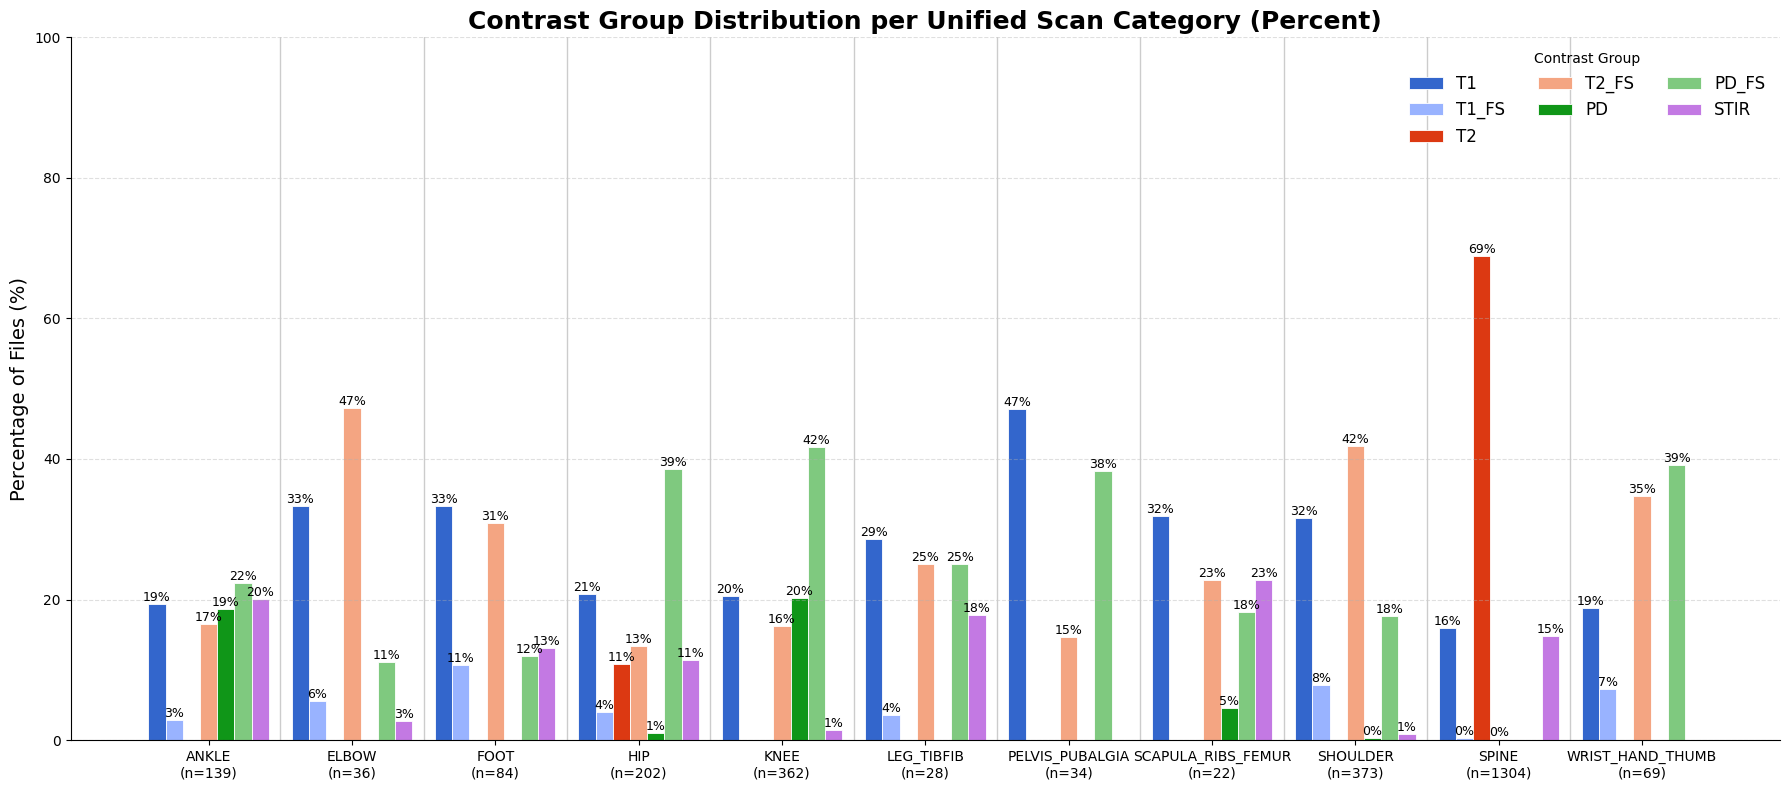

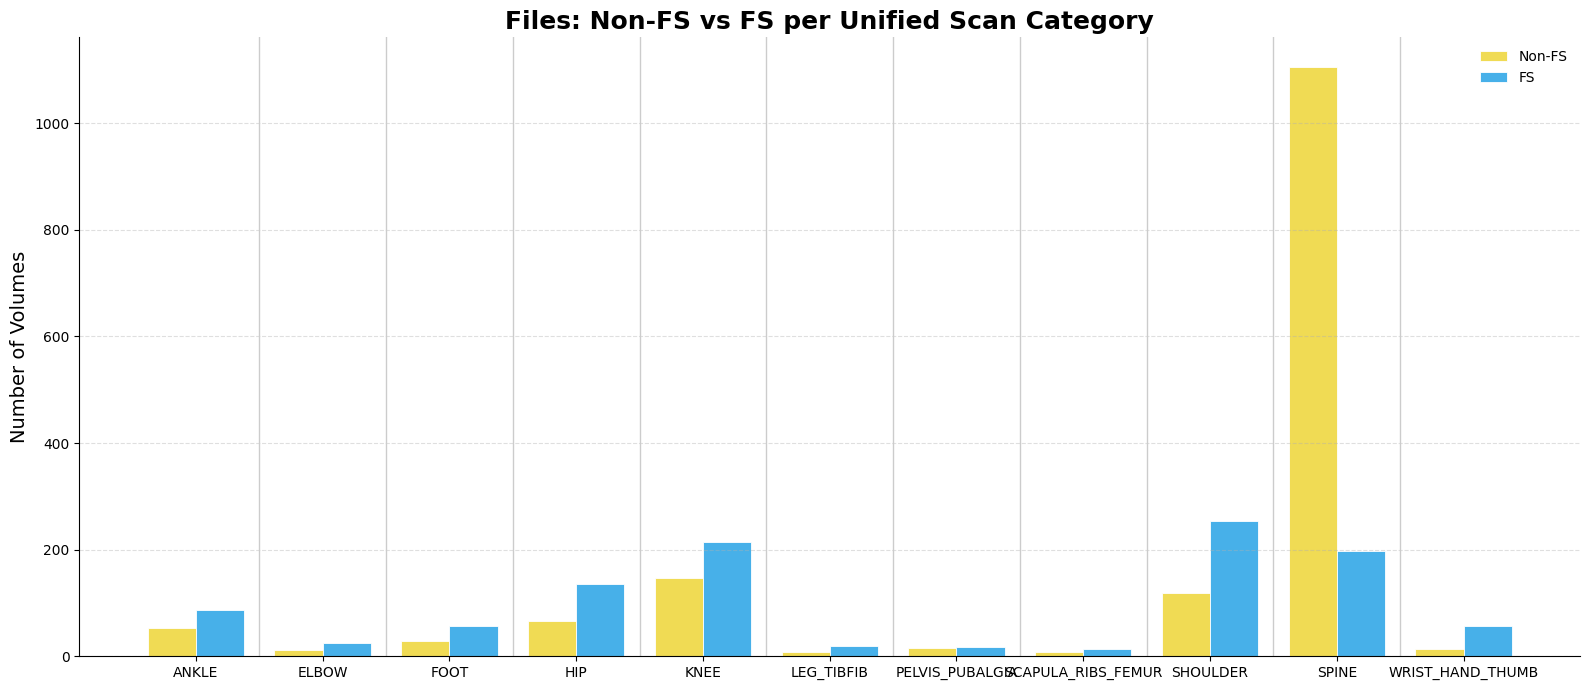

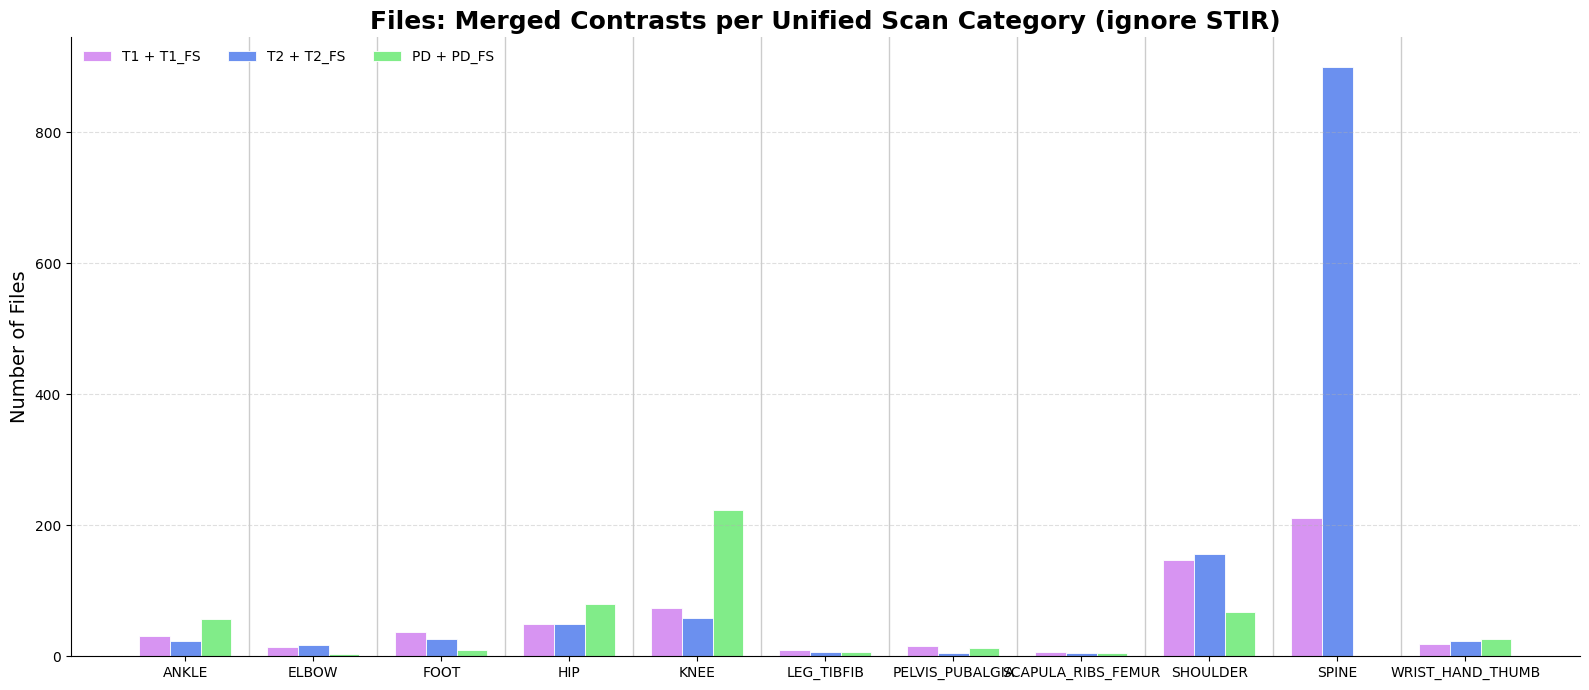

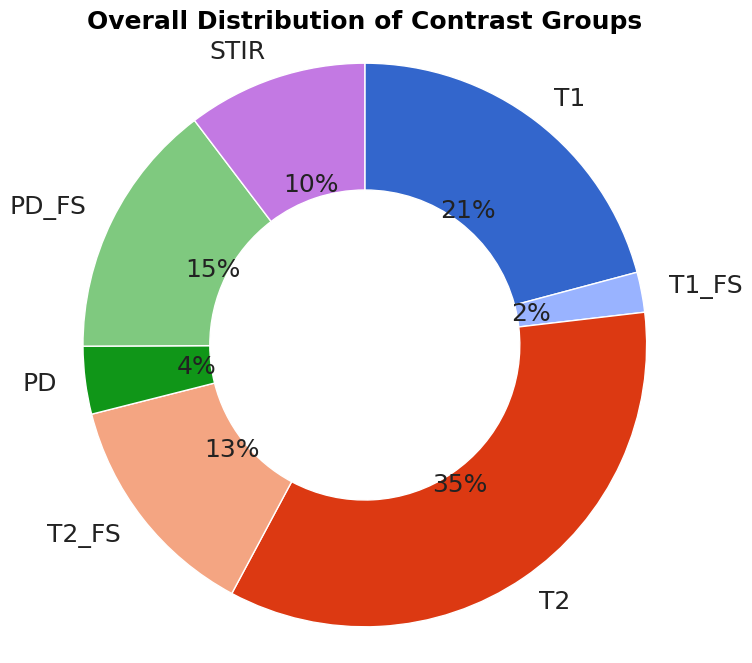

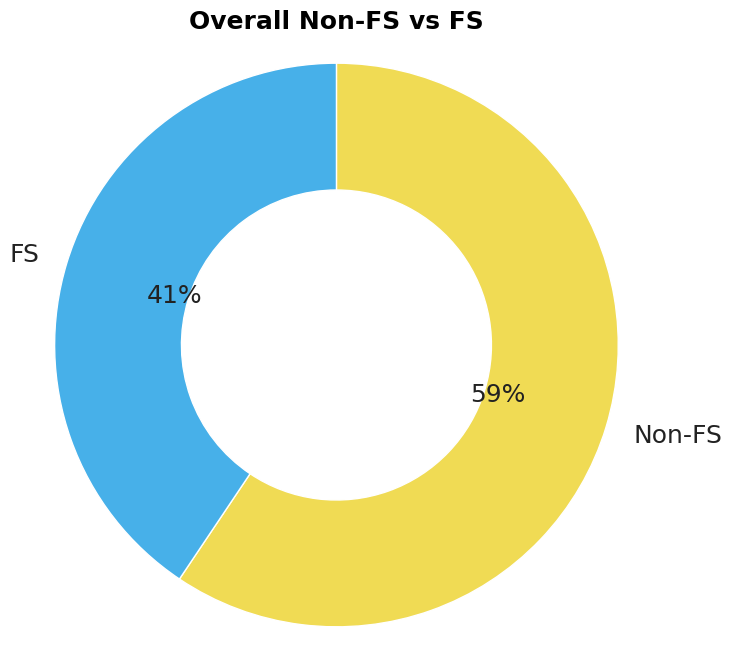

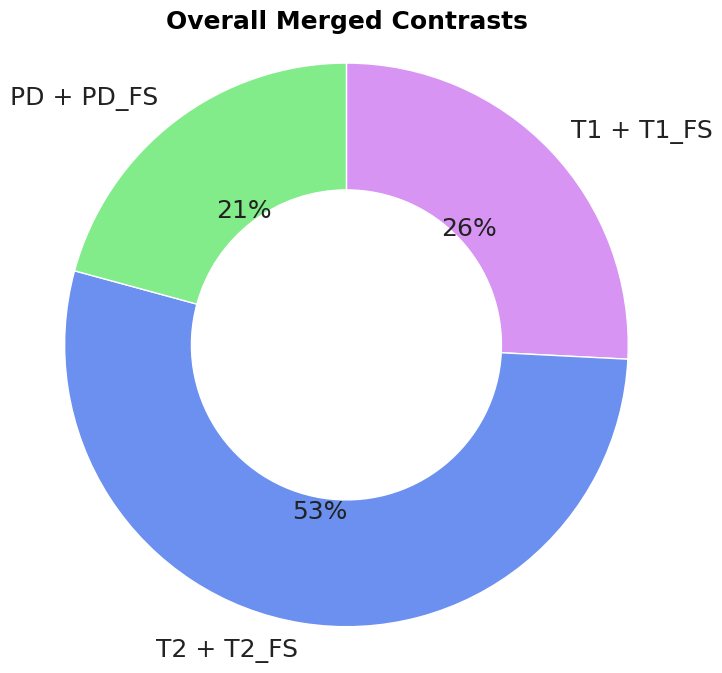

In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib as mpl
import os

# Global styling: Times New Roman and academic-but-fun palette
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'regular'
# Academic but fun palette: balanced saturation and contrast
PRO_COLORS = {
    'T1': '#3366CC',      # strong academic blue
    'T1_FS': '#99B3FF',   # lighter blue
    'T2': '#DC3912',      # scholarly red
    'T2_FS': '#F4A582',   # coral/soft red
    'PD': '#109618',      # deep green
    'PD_FS': '#7FC97F',   # fresh green
    'STIR': "#C379E3",    # regal purple
    'NON_FS': "#F0DB54",
    'FS': "#47B0E9",
    'T1_all': "#D794F2",
    'T2_all': "#6B90EF",
    'PD_all': "#81EC89",
}

# Reuse the already-built mapping from Cell 3 when available:
#   - fname_to_protocol : {basename -> tProtocolName}
#   - get_contrast_group(proto) -> merged contrast group
fname_to_contrast_group = {}
for fname, proto in fname_to_protocol.items():
    cg = get_contrast_group(proto)
    if cg and cg != 'OTHER':
        fname_to_contrast_group[fname] = cg

# Plot per unified scan category distribution of contrast groups (T1, T1_FS, T2, T2_FS, PD, PD_FS, STIR)
def plot_protocol_distribution_per_category():
    proto_groups = ["T1", "T1_FS", "T2", "T2_FS", "PD", "PD_FS", "STIR"]

    per_cat_proto = defaultdict(lambda: defaultdict(int))
    categories = set()

    for rec in matched_records:
        cat = rec.get('category', 'UNKNOWN')
        categories.add(cat)
        pg = fname_to_contrast_group.get(rec['fname'])
        if pg in proto_groups:
            per_cat_proto[cat][pg] += 1

    categories = sorted(categories)

    perc_matrix = []
    totals = []
    for cat in categories:
        total = sum(per_cat_proto[cat].get(pg, 0) for pg in proto_groups)
        totals.append(total)
        if total > 0:
            perc_row = [per_cat_proto[cat].get(pg, 0) * 100.0 / total for pg in proto_groups]
        else:
            perc_row = [0.0 for _ in proto_groups]
        perc_matrix.append(perc_row)

    fig, ax = plt.subplots(figsize=(18, 8))
    x = list(range(len(categories)))
    bw = 0.12

    colors = [PRO_COLORS.get(pg, '#777777') for pg in proto_groups]

    bars = []
    for j, pg in enumerate(proto_groups):
        y = [perc_matrix[i][j] for i in range(len(categories))]
        offset = (j - (len(proto_groups) - 1) / 2) * bw
        b = ax.bar([xi + offset for xi in x], y, width=bw, color=colors[j], label=pg, edgecolor='white', linewidth=0.6)
        bars.append(b)

    for b in bars:
        for rect in b:
            h = rect.get_height()
            if h > 0:
                ax.text(rect.get_x() + rect.get_width()/2, h, f"{round(h)}%", ha='center', va='bottom', fontsize=9)

    for i in range(1, len(categories)):
        ax.axvline(i - 0.5, color='#CCCCCC', linestyle='-', linewidth=1)

    ax.set_title("Contrast Group Distribution per Unified Scan Category (Percent)", fontsize=18)
    ax.set_ylabel("Percentage of Files (%)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{cat}\n(n={totals[i]})" for i, cat in enumerate(categories)], rotation=0)
    ax.set_ylim(0, 100)
    ax.legend(title="Contrast Group", ncols=3, frameon=False, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    plt.show()

# 2) Non-FS vs FS per unified scan category (two bars per category)
def plot_fs_vs_nonfs_per_category():
    categories = set()
    counts = defaultdict(lambda: {'FS': 0, 'NON_FS': 0})

    for rec in matched_records:
        cat = rec.get('category', 'UNKNOWN')
        categories.add(cat)
        pg = fname_to_contrast_group.get(rec['fname'])
        if not pg:
            continue
        is_fs = pg.endswith('_FS') or (pg == 'STIR')
        if is_fs:
            counts[cat]['FS'] += 1
        else:
            counts[cat]['NON_FS'] += 1

    categories = sorted(categories)
    fs_vals = [counts[cat]['FS'] for cat in categories]
    nonfs_vals = [counts[cat]['NON_FS'] for cat in categories]

    x = list(range(len(categories)))
    bw = 0.38

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.bar([xi - bw/2 for xi in x], nonfs_vals, width=bw, label='Non-FS', color=PRO_COLORS['NON_FS'], edgecolor='white', linewidth=0.6)
    ax.bar([xi + bw/2 for xi in x], fs_vals, width=bw, label='FS', color=PRO_COLORS['FS'], edgecolor='white', linewidth=0.6)

    for i in range(1, len(categories)):
        ax.axvline(i - 0.5, color='#CCCCCC', linestyle='-', linewidth=1)

    ax.set_title('Files: Non-FS vs FS per Unified Scan Category', fontsize=18)
    ax.set_ylabel('Number of Volumes', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=0)
    ax.legend(frameon=False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    plt.show()

# 3) Merged contrasts (T1+T1_FS, T2+T2_FS, PD+PD_FS), ignore STIR, per unified scan category
def plot_merged_contrasts_per_category():
    merged_groups = ['T1_all', 'T2_all', 'PD_all']
    categories = set()
    counts = defaultdict(lambda: {mg: 0 for mg in merged_groups})

    for rec in matched_records:
        cat = rec.get('category', 'UNKNOWN')
        categories.add(cat)
        pg = fname_to_contrast_group.get(rec['fname'])
        if not pg or pg == 'STIR':
            continue
        if pg.startswith('T1'):
            counts[cat]['T1_all'] += 1
        elif pg.startswith('T2'):
            counts[cat]['T2_all'] += 1
        elif pg.startswith('PD'):
            counts[cat]['PD_all'] += 1

    categories = sorted(categories)
    t1_vals = [counts[cat]['T1_all'] for cat in categories]
    t2_vals = [counts[cat]['T2_all'] for cat in categories]
    pd_vals = [counts[cat]['PD_all'] for cat in categories]

    x = list(range(len(categories)))
    bw = 0.24

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.bar([xi - bw for xi in x], t1_vals, width=bw, label='T1 + T1_FS', color=PRO_COLORS['T1_all'], edgecolor='white', linewidth=0.6)
    ax.bar(x, t2_vals, width=bw, label='T2 + T2_FS', color=PRO_COLORS['T2_all'], edgecolor='white', linewidth=0.6)
    ax.bar([xi + bw for xi in x], pd_vals, width=bw, label='PD + PD_FS', color=PRO_COLORS['PD_all'], edgecolor='white', linewidth=0.6)

    for i in range(1, len(categories)):
        ax.axvline(i - 0.5, color='#CCCCCC', linestyle='-', linewidth=1)

    ax.set_title('Files: Merged Contrasts per Unified Scan Category (ignore STIR)', fontsize=18)
    ax.set_ylabel('Number of Files', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=0)
    ax.legend(ncols=3, frameon=False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    plt.show()

# 4) Overall pie charts (aggregated across all unified scan categories)
def pie_overall_protocol_groups():
    proto_groups = ["T1", "T1_FS", "T2", "T2_FS", "PD", "PD_FS", "STIR"]
    counter = defaultdict(int)
    for rec in matched_records:
        pg = fname_to_contrast_group.get(rec['fname'])
        if pg in proto_groups:
            counter[pg] += 1
    labels, sizes, colors = [], [], []
    for pg in proto_groups:
        if counter[pg] > 0:
            labels.append(pg)
            sizes.append(counter[pg])
            colors.append(PRO_COLORS.get(pg, '#777777'))
    if not sizes:
        print('No contrast groups to plot.')
        return
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.0f%%',
        startangle=90,
        colors=colors,
        counterclock=False,
        wedgeprops=dict(width=0.45, edgecolor='white'),
        textprops=dict(color='#222222', fontsize=18),
    )
    ax.set_title('Overall Distribution of Contrast Groups', fontsize=18)
    ax.axis('equal')
    plt.show()

def pie_overall_fs_vs_nonfs():
    fs = 0
    nonfs = 0
    for rec in matched_records:
        pg = fname_to_contrast_group.get(rec['fname'])
        if not pg:
            continue
        if pg.endswith('_FS') or pg == 'STIR':
            fs += 1
        else:
            nonfs += 1
    labels = ['Non-FS', 'FS']
    sizes = [nonfs, fs]
    colors = [PRO_COLORS['NON_FS'], PRO_COLORS['FS']]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.0f%%',
        startangle=90,
        colors=colors,
        counterclock=False,
        wedgeprops=dict(width=0.45, edgecolor='white'),
        textprops=dict(color='#222222', fontsize=18),
    )
    ax.set_title('Overall Non-FS vs FS', fontsize=18)
    ax.axis('equal')
    plt.show()

def pie_overall_merged_contrasts():
    t1_all = 0
    t2_all = 0
    pd_all = 0
    for rec in matched_records:
        pg = fname_to_contrast_group.get(rec['fname'])
        if not pg or pg == 'STIR':
            continue
        if pg.startswith('T1'):
            t1_all += 1
        elif pg.startswith('T2'):
            t2_all += 1
        elif pg.startswith('PD'):
            pd_all += 1
    labels = ['T1 + T1_FS', 'T2 + T2_FS', 'PD + PD_FS']
    sizes = [t1_all, t2_all, pd_all]
    colors = [PRO_COLORS['T1_all'], PRO_COLORS['T2_all'], PRO_COLORS['PD_all']]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.0f%%',
        startangle=90,
        colors=colors,
        counterclock=False,
        wedgeprops=dict(width=0.45, edgecolor='white'),
        textprops=dict(color='#222222', fontsize=18),
    )
    ax.set_title('Overall Merged Contrasts', fontsize=18)
    ax.axis('equal')
    plt.show()

# Run all plots
plot_protocol_distribution_per_category()
plot_fs_vs_nonfs_per_category()
plot_merged_contrasts_per_category()
pie_overall_protocol_groups()
pie_overall_fs_vs_nonfs()
pie_overall_merged_contrasts()

/tmp/ipykernel_4035458/3716391449.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = mpl.cm.get_cmap('BuPu')


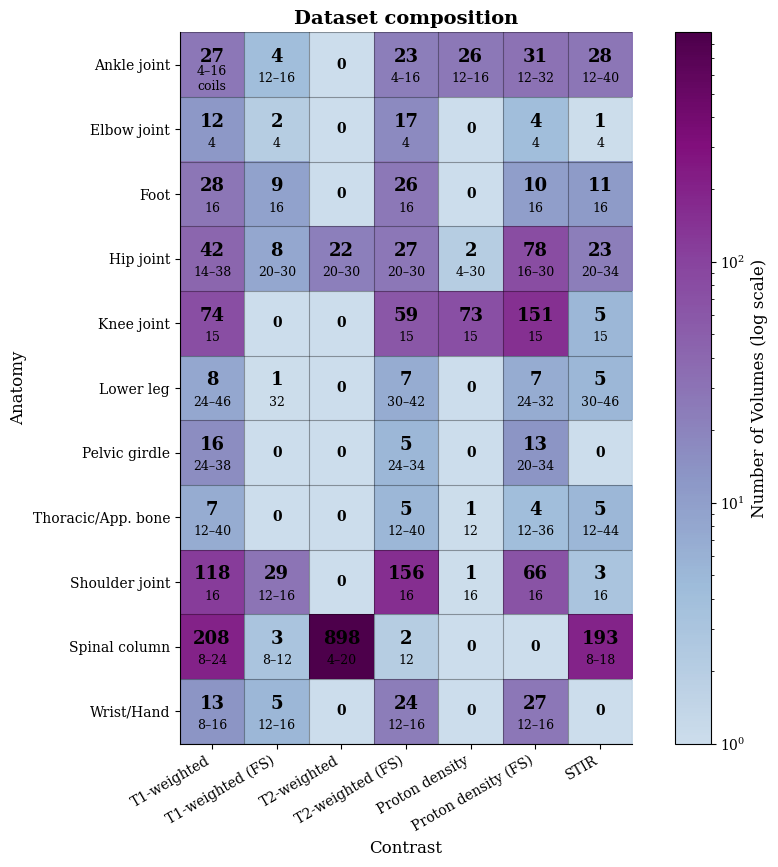

In [8]:
# --- Final figure: Heatmap (Anatomy x Contrast) with per-cell coil-range labels ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from collections import defaultdict
import h5py
import os

# Reuse from previous cells (must exist):
# - matched_records (list of dicts with 'category', 'fname')
# - fname_to_protocol (dict: fname -> tProtocolName)
# - get_contrast_group(proto) -> merged contrast group
# - h5_paths (list of file paths)

# 1) Reuse: fname -> merged contrast group
fname_to_contrast_group = {}
for fname, proto in fname_to_protocol.items():
    cg = get_contrast_group(proto)
    if cg and cg != 'OTHER':
        fname_to_contrast_group[fname] = cg

# 2) Rename anatomies to academic short labels (rows)
ANATOMY_LABELS = {
    'SPINE': 'Spinal column',
    'KNEE': 'Knee joint',
    'SHOULDER': 'Shoulder joint',
    'HIP': 'Hip joint',
    'ANKLE': 'Ankle joint',
    'FOOT': 'Foot',
    'LEG_TIBFIB': 'Lower leg',
    'ELBOW': 'Elbow joint',
    'WRIST_HAND_THUMB': 'Wrist/Hand',
    'PELVIS_PUBALGIA': 'Pelvic girdle',
    'SCAPULA_RIBS_FEMUR': 'Thoracic/App. bone',
}

# 3) Rename contrasts to academic labels (columns)
CONTRAST_ORDER = ['T1', 'T1_FS', 'T2', 'T2_FS', 'PD', 'PD_FS', 'STIR']
CONTRAST_LABELS = {
    'T1': 'T1-weighted',
    'T1_FS': 'T1-weighted (FS)',
    'T2': 'T2-weighted',
    'T2_FS': 'T2-weighted (FS)',
    'PD': 'Proton density',
    'PD_FS': 'Proton density (FS)',
    'STIR': 'STIR',
}

# 4) Build basename->fullpath map for kspace access
basename_to_path = {os.path.basename(p): p for p in h5_paths}

def _infer_num_coils_from_h5(fp: str):
    try:
        with h5py.File(fp, 'r') as f:
            if 'kspace' not in f:
                return None
            ks = f['kspace'].shape
            # expected (slices, coils, H, W)
            if len(ks) >= 2:
                return int(ks[1])
    except Exception:
        return None
    return None

# 5) Aggregate: counts + per-cell coil ranges
anatomy_keys = sorted({rec.get('category', 'UNKNOWN') for rec in matched_records})
anatomy_keys = [k for k in anatomy_keys if k in ANATOMY_LABELS] + [k for k in anatomy_keys if k not in ANATOMY_LABELS]
row_labels = [ANATOMY_LABELS.get(k, k) for k in anatomy_keys]
col_keys = CONTRAST_ORDER
col_labels = [CONTRAST_LABELS.get(c, c) for c in col_keys]

counts = defaultdict(lambda: defaultdict(int))
coil_stats = defaultdict(lambda: defaultdict(list))  # (anat, contrast) -> [num_coils]
for rec in matched_records:
    anat = rec.get('category', 'UNKNOWN')
    if anat not in anatomy_keys:
        continue
    fname = rec['fname']
    cg = fname_to_contrast_group.get(fname)
    if cg not in col_keys:
        continue
    counts[anat][cg] += 1
    fp = basename_to_path.get(fname)
    if fp:
        nc = _infer_num_coils_from_h5(fp)
        if nc is not None:
            coil_stats[anat][cg].append(nc)

heat = np.array([[counts[a].get(c, 0) for c in col_keys] for a in anatomy_keys], dtype=int)

# Precompute coil-range labels per cell
coil_label_grid = [[None for _ in col_keys] for _ in anatomy_keys]
for i, a in enumerate(anatomy_keys):
    for j, c in enumerate(col_keys):
        vals = coil_stats[a].get(c, [])
        if not vals:
            coil_label_grid[i][j] = None
        else:
            coil_label_grid[i][j] = (min(vals), max(vals))

# 6) Academic-style heatmap: log normalization (keep log), but render zeros explicitly
mpl.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, ax = plt.subplots(figsize=(11.5, max(6.0, 0.8 * len(row_labels))))

positive = heat[heat > 0]
vmin = int(positive.min()) if positive.size else 1
vmax = int(heat.max()) if heat.size else 1
norm = LogNorm(vmin=max(vmin, 1), vmax=max(vmax, 1))

# Colormap: start at 0.1 of the original scale (trim low end)
base_cmap = mpl.cm.get_cmap('BuPu')
cmap = LinearSegmentedColormap.from_list(
    'BuPu_from_0p1',
    base_cmap(np.linspace(0.2, 1.0, 256)),
)
cmap.set_bad(base_cmap(0.2))

# Mask zeros so we can color them uniformly (dark blue)
heat_masked = np.ma.masked_where(heat == 0, heat)
im = ax.imshow(heat_masked, cmap=cmap, norm=norm)

# Paint zeros explicitly with a uniform tile matching the cmap start
zero_color = base_cmap(0.2)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if heat[i, j] == 0:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=zero_color, edgecolor='none', zorder=0))

ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=30, ha='right')
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

ax.set_xlabel('Contrast')
ax.set_ylabel('Anatomy')
ax.set_title('Dataset composition')

# Grid lines (subtle, paper style)
ax.set_xticks(np.arange(-.5, len(col_labels), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(row_labels), 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.8, alpha=0.35)
ax.tick_params(which='minor', bottom=False, left=False)

# Annotations: always show file count; show coils as smaller 2nd line when v>0
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = int(heat[i, j])
        if v == 0:
            ax.text(j, i, "0", ha='center', va='center', color='black', fontsize=10, fontweight='bold')
            continue
        cr = coil_label_grid[i][j]
        if cr is None:
            coil_txt = "n/a"
        else:
            cmin, cmax = cr
            if i==0 and j==0:
                coil_txt = str(cmin) if cmin == cmax else f"{cmin}–{cmax}\ncoils" 
            else:
                coil_txt = str(cmin) if cmin == cmax else f"{cmin}–{cmax}"
        # Count (bold + bigger) + coil label (smaller)
        ax.text(j, i - 0.12, f"{v}", ha='center', va='center', color='black', fontsize=13, fontweight='bold')
        ax.text(j, i + 0.22, coil_txt, ha='center', va='center', color='black', fontsize=9)

# Colorbar (log scale)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Number of Volumes (log scale)')

fig.tight_layout()
plt.show()

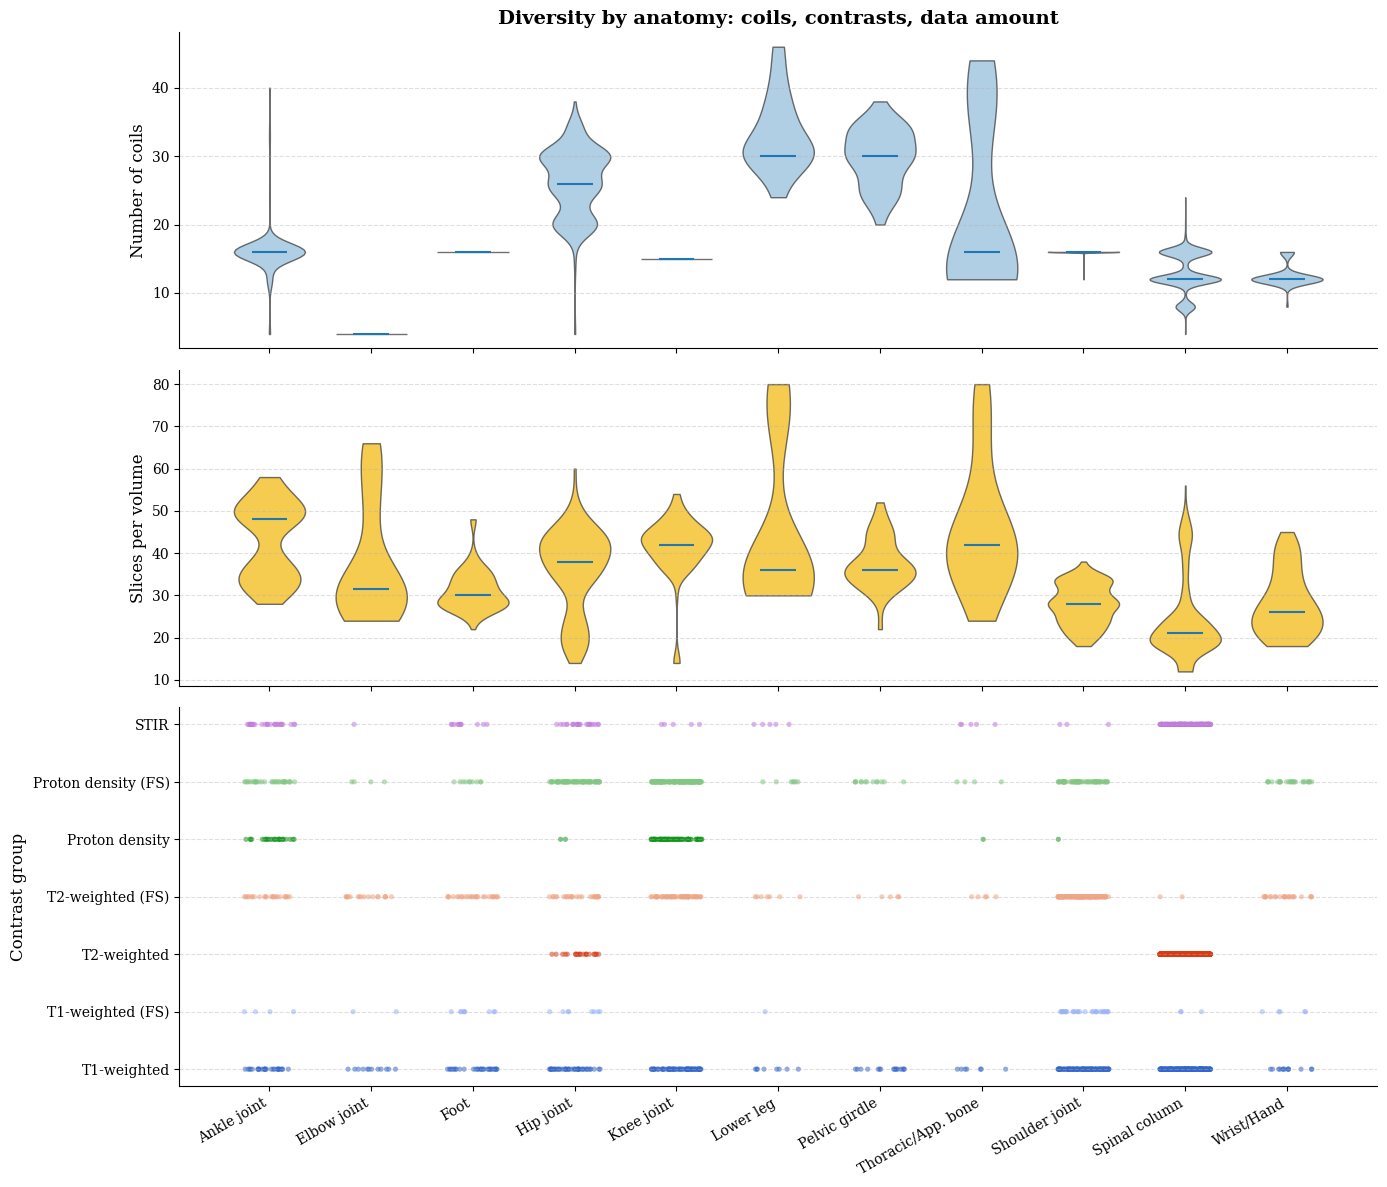

In [9]:
# --- Diversity panel: coils, contrasts, and data amount per anatomy ---
import numpy as np
import matplotlib.pyplot as plt
import os

# Fallback labels if the previous cell was not run
if 'ANATOMY_LABELS' not in globals():
    ANATOMY_LABELS = {
        'SPINE': 'Spinal column',
        'KNEE': 'Knee joint',
        'SHOULDER': 'Shoulder joint',
        'HIP': 'Hip joint',
        'ANKLE': 'Ankle joint',
        'FOOT': 'Foot',
        'LEG_TIBFIB': 'Lower leg',
        'ELBOW': 'Elbow joint',
        'WRIST_HAND_THUMB': 'Wrist/Hand',
        'PELVIS_PUBALGIA': 'Pelvic girdle',
        'SCAPULA_RIBS_FEMUR': 'Thoracic/App. bone',
    }

if 'CONTRAST_ORDER' not in globals():
    CONTRAST_ORDER = ['T1', 'T1_FS', 'T2', 'T2_FS', 'PD', 'PD_FS', 'STIR']

if 'CONTRAST_LABELS' not in globals():
    CONTRAST_LABELS = {
        'T1': 'T1-weighted',
        'T1_FS': 'T1-weighted (FS)',
        'T2': 'T2-weighted',
        'T2_FS': 'T2-weighted (FS)',
        'PD': 'Proton density',
        'PD_FS': 'Proton density (FS)',
        'STIR': 'STIR',
    }

if 'fname_to_contrast_group' not in globals():
    fname_to_contrast_group = {}
    for fname, proto in fname_to_protocol.items():
        cg = get_contrast_group(proto)
        if cg and cg != 'OTHER':
            fname_to_contrast_group[fname] = cg

if 'basename_to_path' not in globals():
    basename_to_path = {os.path.basename(p): p for p in h5_paths}

if '_infer_num_coils_from_h5' not in globals():
    def _infer_num_coils_from_h5(fp):
        try:
            import h5py
            with h5py.File(fp, 'r') as f:
                if 'kspace' not in f:
                    return None
                ks = f['kspace'].shape
                if len(ks) >= 2:
                    return int(ks[1])
        except Exception:
            return None
        return None

anatomy_keys = sorted({rec.get('category', 'UNKNOWN') for rec in matched_records})
anatomy_keys = [k for k in anatomy_keys if k in ANATOMY_LABELS] + [k for k in anatomy_keys if k not in ANATOMY_LABELS]
row_labels = [ANATOMY_LABELS.get(k, k) for k in anatomy_keys]

# Precompute coil counts once per file
coil_by_fname = {}
for rec in matched_records:
    fname = rec['fname']
    if fname in coil_by_fname:
        continue
    fp = basename_to_path.get(fname)
    if fp:
        coil_by_fname[fname] = _infer_num_coils_from_h5(fp)

coil_by_anat = []
slice_by_anat = []
contrast_by_anat = []

for anat in anatomy_keys:
    coil_vals = []
    slice_vals = []
    contrast_vals = []
    for rec in matched_records:
        if rec.get('category', 'UNKNOWN') != anat:
            continue
        sc = rec.get('slice_count')
        if sc is not None:
            slice_vals.append(int(sc))
        cg = fname_to_contrast_group.get(rec['fname'])
        if cg in CONTRAST_ORDER:
            contrast_vals.append(cg)
        nc = coil_by_fname.get(rec['fname'])
        if nc is not None:
            coil_vals.append(int(nc))
    coil_by_anat.append(coil_vals)
    slice_by_anat.append(slice_vals)
    contrast_by_anat.append(contrast_vals)

positions = np.arange(1, len(anatomy_keys) + 1)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1.2]})

def _violin(ax, data, pos, color):
    idx = [i for i, vals in enumerate(data) if len(vals) > 0]
    if not idx:
        return
    plot_data = [data[i] for i in idx]
    plot_pos = [pos[i] for i in idx]
    parts = ax.violinplot(plot_data, positions=plot_pos, showmedians=True, showextrema=False, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('#333333')
        pc.set_alpha(0.7)

_violin(axes[0], coil_by_anat, positions, color='#8FBAD9')
axes[0].set_ylabel('Number of coils')
axes[0].set_title('Diversity by anatomy: coils, contrasts, data amount')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

_violin(axes[1], slice_by_anat, positions, color='#F2B705')
axes[1].set_ylabel('Slices per volume')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

contrast_to_idx = {c: i for i, c in enumerate(CONTRAST_ORDER)}
contrast_labels = [CONTRAST_LABELS.get(c, c) for c in CONTRAST_ORDER]

if 'PRO_COLORS' in globals():
    contrast_colors = PRO_COLORS
else:
    contrast_colors = {}

for i, vals in enumerate(contrast_by_anat):
    if not vals:
        continue
    xs = positions[i] + np.random.uniform(-0.25, 0.25, size=len(vals))
    ys = [contrast_to_idx[v] for v in vals]
    cs = [contrast_colors.get(v, '#555555') for v in vals]
    axes[2].scatter(xs, ys, s=14, alpha=0.55, c=cs, edgecolors='none')

axes[2].set_ylabel('Contrast group')
axes[2].set_yticks(range(len(CONTRAST_ORDER)))
axes[2].set_yticklabels(contrast_labels)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].set_xticks(positions)
axes[2].set_xticklabels(row_labels, rotation=30, ha='right')

plt.tight_layout()
plt.show()
